# Imports

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import matplotlib.pyplot as plt
import plotly
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# EDA

In [9]:
# Define the ticker symbol
ticker_symbol = 'HINDUNILVR.NS'  # Example: Hindustan Unilever Ltd.

# Set the start and end dates for the historical data
start_date = '2000-01-01'
end_date = '2024-03-03'

# Fetch historical data from Yahoo Finance
df = yf.download(ticker_symbol, start=start_date, end=end_date)

# Reset the index to make 'Date' a column
df.reset_index(inplace=True)

[*********************100%%**********************]  1 of 1 completed


In [10]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,6036.000000,6036.000000,6036.000000,6036.000000,6036.000000,6.036000e+03
mean,840.198551,848.935204,830.625174,839.748478,756.473105,2.041216e+06
std,831.531998,838.679180,823.506610,830.998986,822.276681,2.874746e+06
min,103.099998,108.000000,100.500000,106.150002,70.419968,0.000000e+00
25%,216.899994,220.000000,213.212502,216.387497,139.807014,1.044182e+06
50%,384.250000,388.050003,380.600006,384.250000,310.624741,1.590601e+06
75%,1326.950012,1339.100006,1314.437500,1330.887482,1208.748749,2.465288e+06
max,2827.899902,2859.300049,2796.649902,2812.449951,2737.026123,1.856699e+08


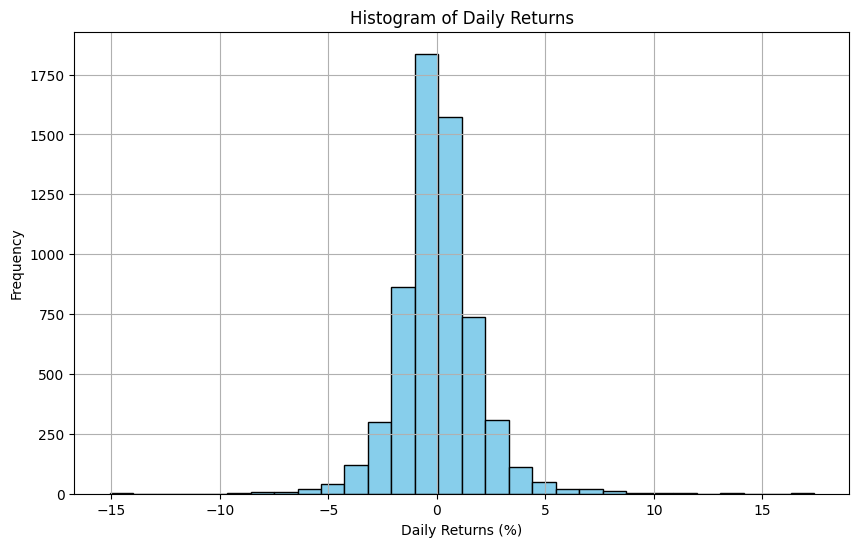

In [11]:
# Calculate daily returns
df['Daily_Returns'] = df['Close'].pct_change() * 100

# Drop the first row since it will have NaN value for Daily_Returns
df.dropna(inplace=True)

# Plot histogram for daily returns
plt.figure(figsize=(10, 6))
plt.hist(df['Daily_Returns'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Daily Returns')
plt.xlabel('Daily Returns (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [12]:
pip install mplfinance

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.3.1 -> 24.0
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
import mplfinance as mpf

In [19]:
# Define the ticker symbol
ticker_symbol = 'HINDUNILVR.NS'  # Example: Hindustan Unilever Ltd.

# Set the start and end dates for the historical data
start_date = '2024-02-20'
end_date = '2024-03-03'

# Fetch historical data from Yahoo Finance
df = yf.download(ticker_symbol, start=start_date, end=end_date)

# Reset the index to make 'Date' a column
df.reset_index(inplace=True)

[*********************100%%**********************]  1 of 1 completed


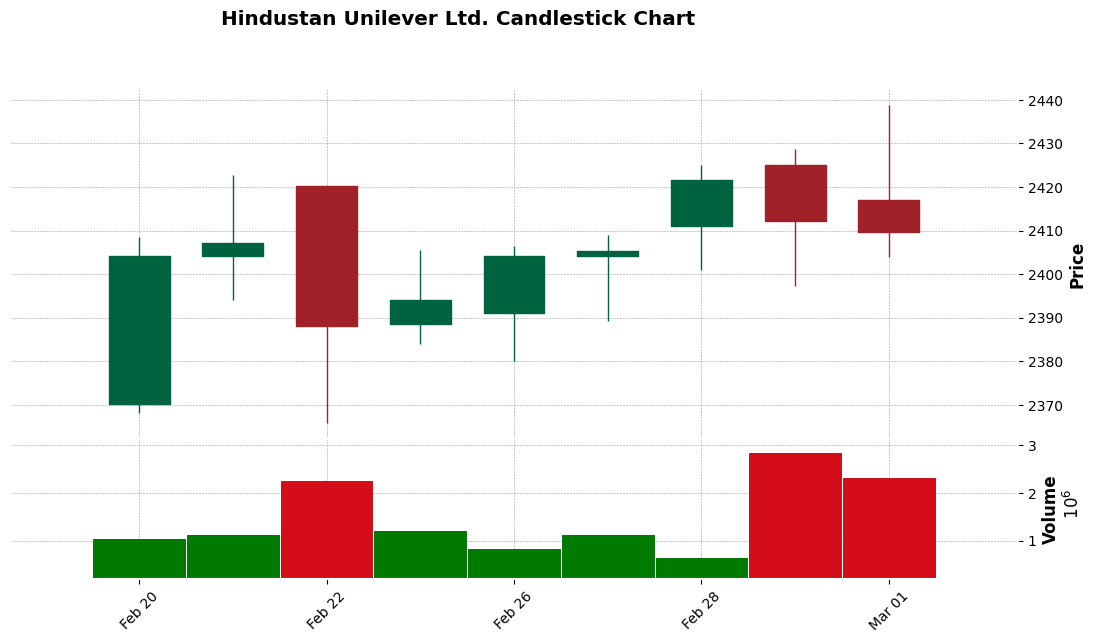

In [20]:
mpf.plot(df.set_index('Date'), type='candle', style='charles', title='Hindustan Unilever Ltd. Candlestick Chart',
         ylabel='Price', ylabel_lower='Volume', volume=True, mav=(10,20), figratio=(18,10), figsize=(14,7))

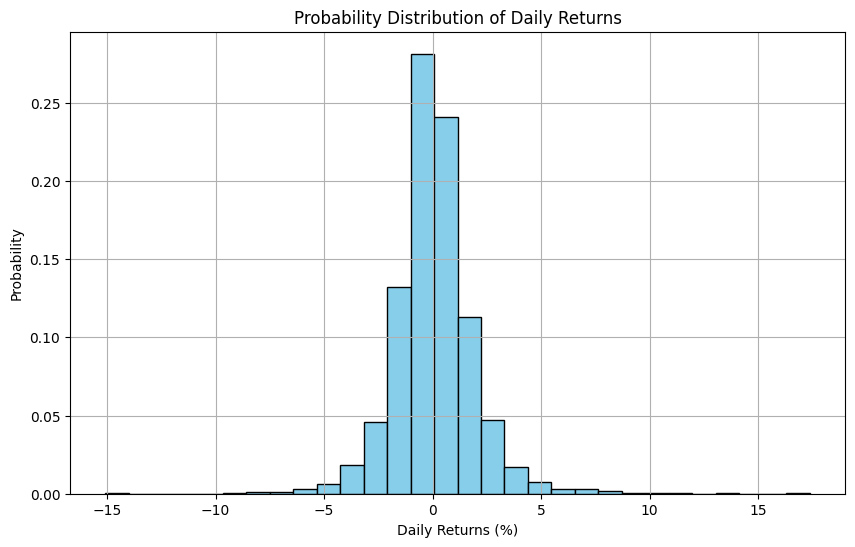

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate daily returns
df['Daily_Returns'] = df['Close'].pct_change() * 100

# Drop the first row since it will have NaN value for Daily_Returns
df.dropna(inplace=True)

# Plot histogram for daily returns
plt.figure(figsize=(10, 6))
plt.hist(df['Daily_Returns'], bins=30, color='skyblue', edgecolor='black', density=True)
plt.title('Probability Distribution of Daily Returns')
plt.xlabel('Daily Returns (%)')
plt.ylabel('Probability')
plt.grid(True)
plt.show()


In [20]:

df['Daily_Returns'] = df['Close'].pct_change() * 100


df.dropna(inplace=True)


expected_value = df['Daily_Returns'].mean()

print("Expected Value (Mean) of Daily Returns:", expected_value)

expected_profilt = 100000*1.0005616699136650273
expected_profilt

Expected Value (Mean) of Daily Returns: 0.05413628278249718


100561.66991366501

In [21]:
# Calculate the number of days with positive returns
positive_returns_count = (df['Daily_Returns'] > 0).sum()

# Calculate the total number of days
total_days = len(df['Daily_Returns'])

# Calculate the probability of making positive returns
probability_positive_returns = positive_returns_count / total_days

print("Probability of Making Positive Returns:", probability_positive_returns)


Probability of Making Positive Returns: 0.4906286282965666


In [31]:
df1 = yf.download('^NSEI', start=start_date, end=end_date)
df1.reset_index(inplace=True)

[*********************100%%**********************]  1 of 1 completed


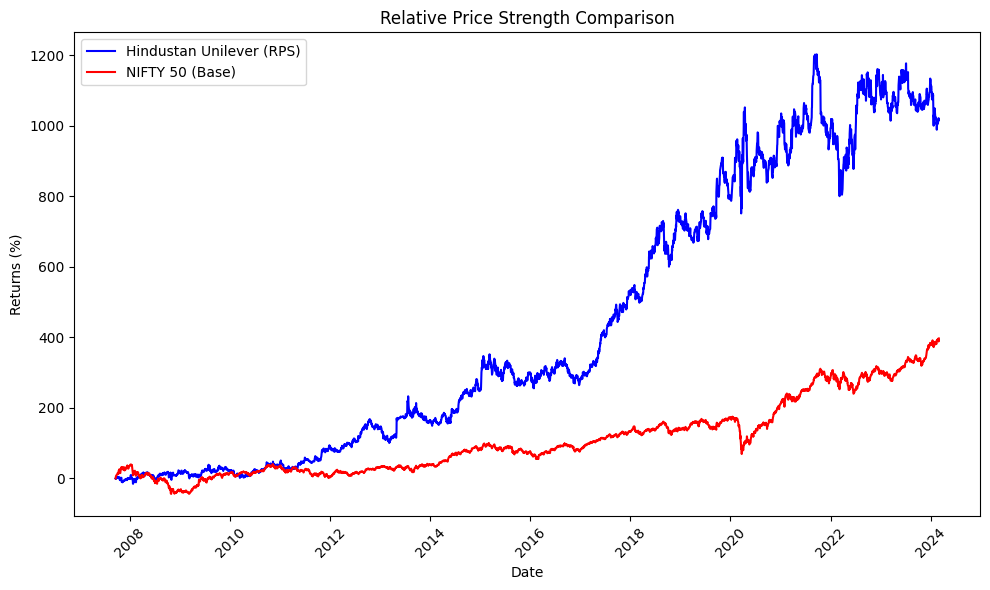

In [34]:
import matplotlib.pyplot as plt

# Calculate the Relative Price Strength (RPS)
hindustan_prices = df[df['Date'] >= start_date_nifty]['Close']
nifty_prices = df1[df1['Date'] >= start_date_nifty]['Close']

# Calculate the percentage returns from the base price
base_hindustan = hindustan_prices.iloc[0]
base_nifty = nifty_prices.iloc[0]

percentage_returns_hindustan = ((hindustan_prices - base_hindustan) / base_hindustan) * 100
percentage_returns_nifty = ((nifty_prices - base_nifty) / base_nifty) * 100

# Plotting the Relative Price Strength
plt.figure(figsize=(10, 6))

# Plotting Hindustan Unilever Relative Price Strength
plt.plot(df[df['Date'] >= start_date_nifty]['Date'], percentage_returns_hindustan, label='Hindustan Unilever (RPS)', color='blue')

# Plotting NIFTY 50 Relative Price Strength
plt.plot(df1[df1['Date'] >= start_date_nifty]['Date'], percentage_returns_nifty, label='NIFTY 50 (Base)', color='red')

# Adding titles and labels
plt.title('Relative Price Strength Comparison')
plt.xlabel('Date')
plt.ylabel('Returns (%)')
plt.legend()

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Show plot
plt.tight_layout()
plt.show()


        Date        Open        High         Low       Close   Adj Close  \
0 2000-01-03  230.000000  230.755005  230.000000  230.755005  132.422195   
1 2000-01-04  238.100006  238.100006  225.000000  228.104996  130.901413   
2 2000-01-05  220.000000  225.000000  210.500000  219.990005  126.244591   
3 2000-01-06  222.490005  236.000000  221.000000  228.820007  131.311798   
4 2000-01-07  230.000000  245.199997  228.225006  241.294998  138.470734   

    Volume  
0   249030  
1   585140  
2   802960  
3  1900320  
4  1925820  
              Open         High          Low        Close    Adj Close  \
count  6036.000000  6036.000000  6036.000000  6036.000000  6036.000000   
mean    840.198551   848.935204   830.625174   839.748478   756.473104   
std     831.531998   838.679180   823.506610   830.998986   822.276681   
min     103.099998   108.000000   100.500000   106.150002    70.419991   
25%     216.899994   220.000000   213.212502   216.387497   139.807007   
50%     384.250000   

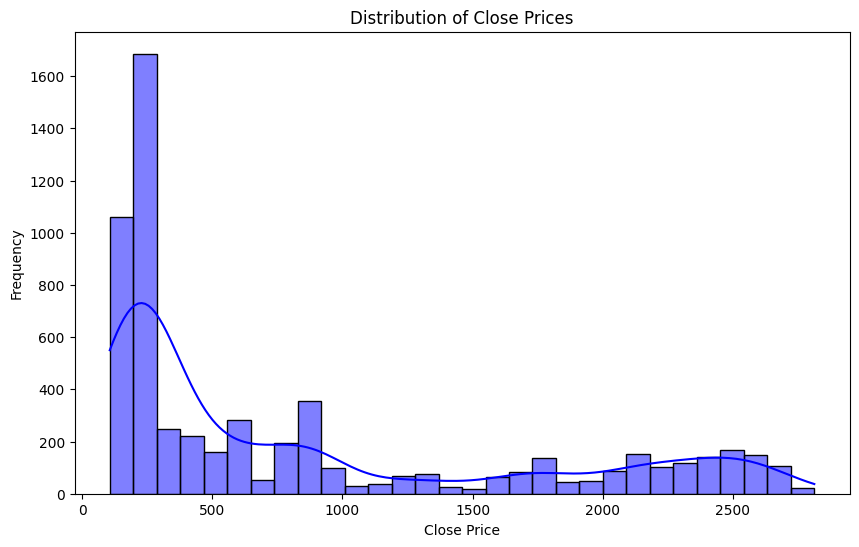

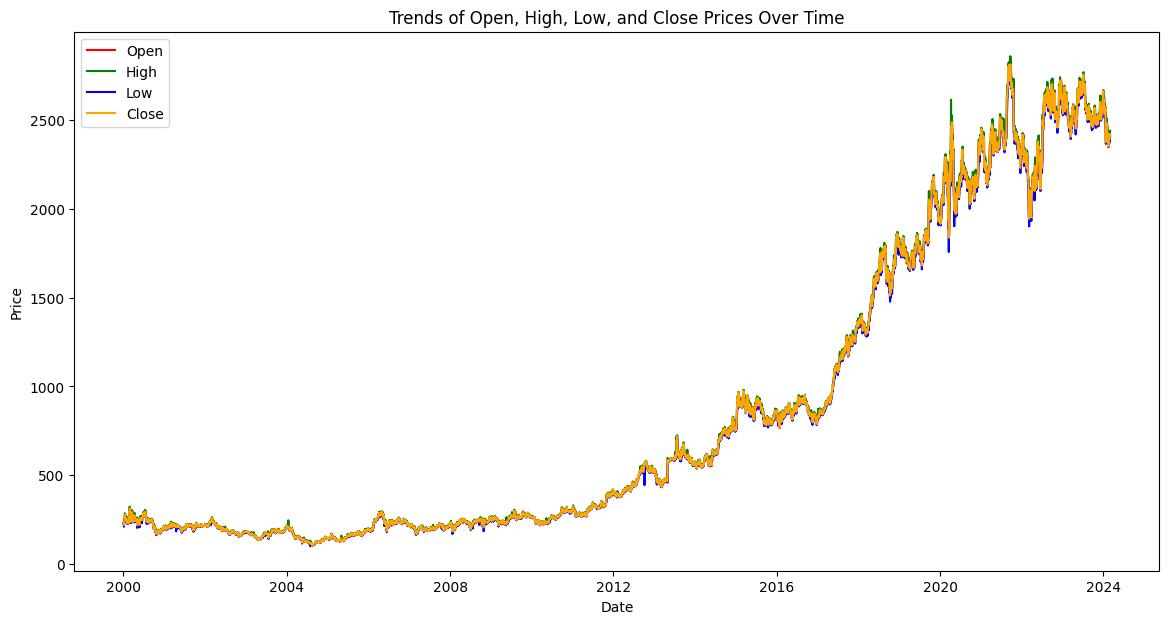

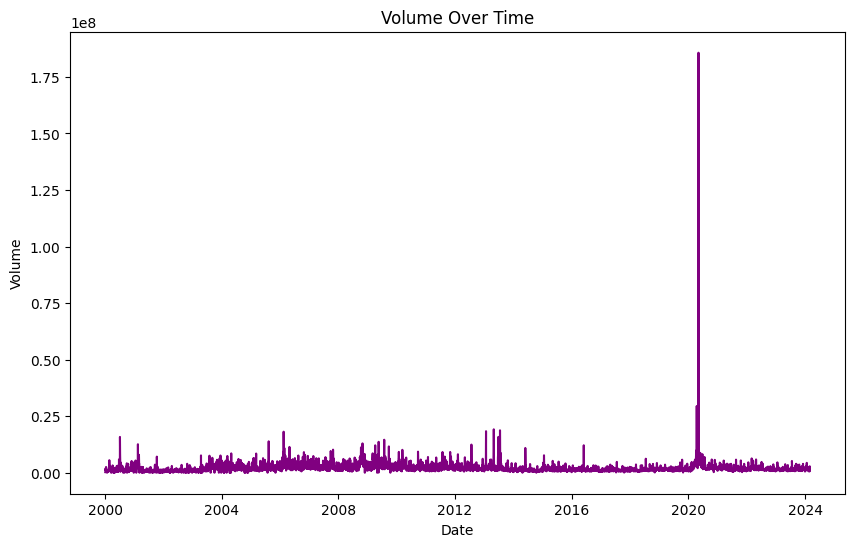

In [11]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have fetched the data already, let's proceed with EDA

# Load the data into a DataFrame
# You already have it in the 'df' DataFrame

# Display the first few rows of the DataFrame
print(df.head())

# Display summary statistics of the numerical columns
print(df.describe())

# Check for missing values
print(df.isnull().sum())

# Plot the distribution of 'Close' prices
plt.figure(figsize=(10, 6))
sns.histplot(df['Close'], bins=30, kde=True, color='blue')
plt.title('Distribution of Close Prices')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.show()

# Plotting trends of 'Open', 'High', 'Low', and 'Close' prices over time
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Open'], label='Open', color='red')
plt.plot(df['Date'], df['High'], label='High', color='green')
plt.plot(df['Date'], df['Low'], label='Low', color='blue')
plt.plot(df['Date'], df['Close'], label='Close', color='orange')
plt.title('Trends of Open, High, Low, and Close Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Plotting volume over time
plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['Volume'], color='purple')
plt.title('Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()


In [2]:


# Load the data into a DataFrame
# Assuming you have fetched the data already, let's proceed with EDA

# Display the first few rows of the DataFrame
print(df.head())

# Display summary statistics of the numerical columns
print(df.describe())

# Check for missing values
print(df.isnull().sum())

# Correlation matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

# Pairplot for visualizing relationships between variables
sns.pairplot(df[['Open', 'High', 'Low', 'Close', 'Volume']], diag_kind='kde')
plt.title('Pairplot of Open, High, Low, Close, and Volume')
plt.show()

# Time series plot of 'Close' price
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Close'], color='blue')
plt.title('Time Series Plot of Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

# Boxplot of 'Close' price by year
df['Year'] = df['Date'].dt.year
plt.figure(figsize=(12, 6))
sns.boxplot(x='Year', y='Close', data=df)
plt.title('Boxplot of Close Price by Year')
plt.xlabel('Year')
plt.ylabel('Close Price')
plt.show()

# Interactive candlestick plot using Plotly
fig = px.line(df, x='Date', y='Close', title='Interactive Candlestick Plot of Close Price')
fig.update_xaxes(type='category')
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

# Histogram of volume distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Volume'], bins=30, kde=True, color='green')
plt.title('Distribution of Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.show()

# Trend analysis of 'Close' price over time
plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Close', data=df, color='purple')
plt.title('Trend Analysis of Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()


NameError: name 'df' is not defined